# Notebook 10 - Rainfall dataset selection and preprocessing

Which rainfall data should force MGB-SA? Three questions, in the order they have to be answered:

1. **Is the conventional gauge dataset even clean?** Section 1 finds and repairs a defect that
   invalidated the earlier version of this notebook: 55 stations had their dry days deleted.
2. **Conventional or automatic gauges?** Section 2.
3. **Gauges alone, or gauges plus CHIRPS?** Sections 3-5, including an honest test of *our own*
   interpolated field against the same yardstick we apply to CHIRPS.

**This notebook was rebuilt after a bug was found.** An earlier version concluded that CHIRPS should
be rejected because it damps rainfall extremes. Section 4 shows that our own gauge interpolation damps
them by an essentially identical amount, so that argument does not discriminate between the two. The
conclusion changed once the right measurement was made.

In [1]:
import glob, pathlib
import numpy as np, pandas as pd, rasterio
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.dpi': 96})

REPO = None
for b in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
    if (b/'data'/'processed'/'minibacias.tif').exists():
        REPO = b; break
proc = REPO/'data'/'processed'; raw = REPO/'data'/'raw'/'observed'/'precip'; clim = REPO/'data'/'raw'/'climate'

# repaired conventional dataset (src/repair_precip_zero_suppression.py)
cv = pd.read_csv(proc/'precip_gauges_inventory_qc.csv', dtype={'code': str}).dropna(subset=['lat', 'lon'])
cvd = pd.read_csv(proc/'precip_gauges_daily_qc.csv', dtype={'code': str}).dropna(subset=['precip_mm'])
cvd['date'] = pd.to_datetime(cvd['date'])
rep = pd.read_csv(proc/'precip_zero_suppression_report.csv', dtype={'code': str})

# automatic (telemetric) network
au = pd.read_csv(raw/'precip_auto_stations.csv', dtype={'code': str}).dropna(subset=['lat', 'lon'])
aud = pd.read_csv(raw/'precip_auto_daily_long.csv', dtype={'code': str})
aud['date'] = pd.to_datetime(aud['date'])
if 'valid' in aud:
    aud = aud[aud.valid == 1]

with rasterio.open(proc/'minibacias.tif') as src:
    lab = src.read(1); bn = src.bounds; tf = src.transform
EXT = (bn.left, bn.right, bn.bottom, bn.top)
BASIN = np.where(lab > 0, 1.0, np.nan)

def km(a, o, c, d):
    return np.sqrt(((a-c)*111.)**2 + ((o-d)*111.*np.cos(np.radians((a+c)/2)))**2)

print(f'CONVENTIONAL (repaired): {cv.code.nunique()} stations, {len(cvd):,} station-days  '
      f'{cvd.date.min().date()} -> {cvd.date.max().date()}')
print(f'AUTOMATIC              : {au.code.nunique()} stations, {len(aud):,} station-days')

CONVENTIONAL (repaired): 294 stations, 775,835 station-days  2008-01-01 -> 2018-12-31
AUTOMATIC              : 94 stations, 70,367 station-days


## 1 - Preprocessing: the zero-suppression defect

**What was wrong.** 55 of 294 stations contained only *rain* days - their dry days were never exported
by DHIME. Diagnostic signature: a healthy gauge in this basin records a dry day (<= 0.1 mm) on ~45 % of
its records; the affected stations sat at ~8 %, with median daily values near 20 mm where a healthy
station is near 0.8 mm.

**Why the previous QC missed it.** `build_precip_gauges.py` screens outlier *values* (0-400 mm/day).
Every individual reading in a zero-suppressed series is perfectly plausible - the defect lies in the
*absent* records, which no value filter can see. The spatial-consistency test in notebook 11 also
passed it, for the same structural reason: it looks for values that disagree with neighbours, not for
missing ones.

**Why it mattered.** In IDW interpolation a gauge contributes only on days it reported. A
zero-suppressed gauge therefore joins the weighted average exactly when it is raining there, and is
masked out when it is dry - so it can only ever pull the estimate upward. This produced the circular
wet "bullseyes" in notebook 11's mean-annual rainfall map and inflated some annual totals to
9,000-12,000 mm/yr in a region that receives ~2,000-2,500.

**The repair.** Within each flagged station's own active span, absent calendar days are inserted as
0.0 mm and marked `Inferido_seco`. Nothing is invented outside the span, and healthy stations are
untouched. The test that this is the right diagnosis: the repair has to move the totals into a
plausible range - and it does, landing them on top of the healthy stations rather than anywhere
arbitrary.

flagged 55 / 294 stations (19 %), 92,209 station-days
  dry-day fraction : flagged 0.08  vs healthy 0.45
  median daily mm  : flagged 4.5  vs healthy 0.8
  annual mm/yr     : flagged 3389 -> 1787   (healthy 2156)
  inferred dry days added: 89,083


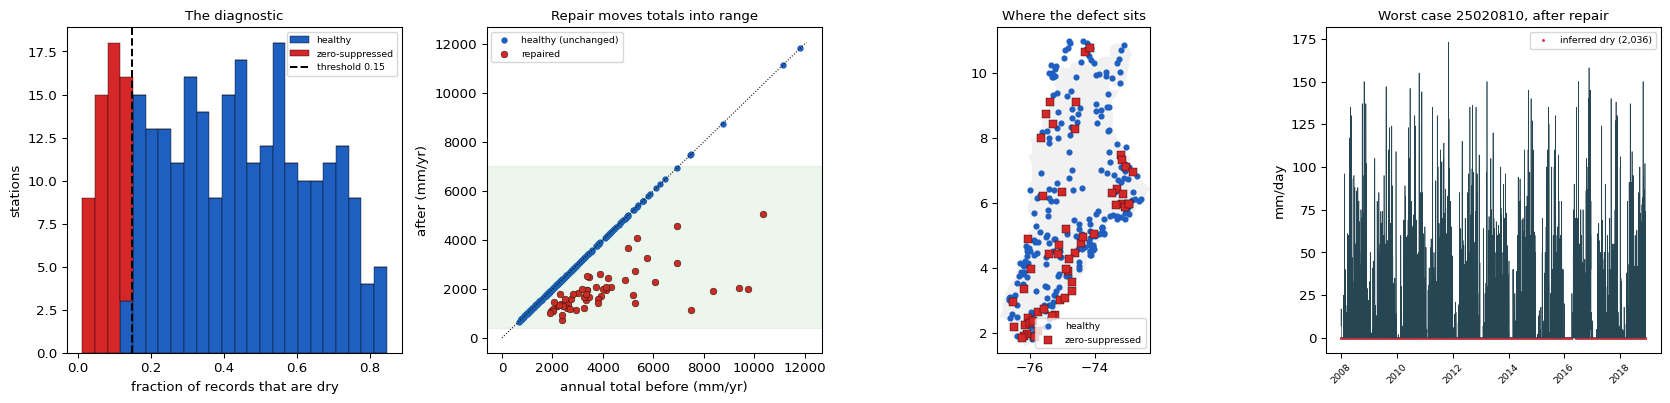

In [2]:
flag = rep[rep.zero_suppressed]
hea = rep[~rep.zero_suppressed]
print(f'flagged {len(flag)} / {len(rep)} stations ({100*len(flag)/len(rep):.0f} %), '
      f'{flag.n_rec.sum():,} station-days')
print(f'  dry-day fraction : flagged {flag.dry_frac.median():.2f}  vs healthy {hea.dry_frac.median():.2f}')
print(f'  median daily mm  : flagged {flag.median_mm.median():.1f}  vs healthy {hea.median_mm.median():.1f}')
print(f'  annual mm/yr     : flagged {flag.ann_before.median():.0f} -> {flag.ann_after.median():.0f}'
      f'   (healthy {hea.ann_before.median():.0f})')
print(f'  inferred dry days added: {int(cv.n_infilled.sum()):,}')

fig, ax = plt.subplots(1, 4, figsize=(17.5, 4.3))
ax[0].hist([hea.dry_frac, flag.dry_frac], bins=24, stacked=True,
           color=['#1f5fbf', '#d62728'], label=['healthy', 'zero-suppressed'], edgecolor='k', lw=.3)
ax[0].axvline(0.15, color='k', ls='--', label='threshold 0.15')
ax[0].set_xlabel('fraction of records that are dry'); ax[0].set_ylabel('stations')
ax[0].set_title('The diagnostic', fontsize=10); ax[0].legend(fontsize=7)

ax[1].scatter(hea.ann_before, hea.ann_before, s=14, c='#1f5fbf', label='healthy (unchanged)')
ax[1].scatter(flag.ann_before, flag.ann_after, s=26, c='#d62728', edgecolor='k', lw=.3, label='repaired')
lim = [0, rep.ann_before.max()*1.02]
ax[1].plot(lim, lim, 'k:', lw=.8); ax[1].axhspan(400, 7000, color='green', alpha=.07)
ax[1].set_xlabel('annual total before (mm/yr)'); ax[1].set_ylabel('after (mm/yr)')
ax[1].set_title('Repair moves totals into range', fontsize=10); ax[1].legend(fontsize=7)

ax[2].imshow(BASIN, extent=EXT, origin='upper', cmap='Greys', vmin=0, vmax=4, alpha=.35)
m = cv.zero_suppressed.fillna(False).astype(bool)
ax[2].scatter(cv.loc[~m, 'lon'], cv.loc[~m, 'lat'], s=13, c='#1f5fbf', label='healthy')
ax[2].scatter(cv.loc[m, 'lon'], cv.loc[m, 'lat'], s=30, c='#d62728', marker='s',
              edgecolor='k', lw=.3, label='zero-suppressed')
ax[2].legend(fontsize=7); ax[2].set_title('Where the defect sits', fontsize=10)

worst = flag.sort_values('ann_before', ascending=False).code.iloc[0]
s = cvd[cvd.code == worst].set_index('date').precip_mm
ax[3].plot(s.index, s.values, lw=.5, color='#264653')
inf = cvd[(cvd.code == worst) & (cvd.approval == 'Inferido_seco')]
ax[3].scatter(inf.date, inf.precip_mm, s=1.5, c='#e63946', label=f'inferred dry ({len(inf):,})')
ax[3].set_ylabel('mm/day'); ax[3].legend(fontsize=7)
ax[3].tick_params(axis='x', rotation=45, labelsize=7)
ax[3].set_title(f'Worst case {worst}, after repair', fontsize=10)
plt.tight_layout(); plt.show()

## 2 - Conventional vs automatic gauges

Both networks are IDEAM. "Automatic telemetry versus IDEAM" is a category error one meets in
secondary sources: telemetry is a *measurement technology*, IDEAM is the *provider*, and IDEAM runs
both networks. The real choice is between a manual daily network and a telemetric one.

Telemetry's genuine advantage is sub-hourly resolution - which MGB **cannot use**, because the model
steps daily and any sub-daily detail is summed away at the first step of the pipeline. What the model
does need is spatial density, record length and unbiased totals. Four tests on exactly those.

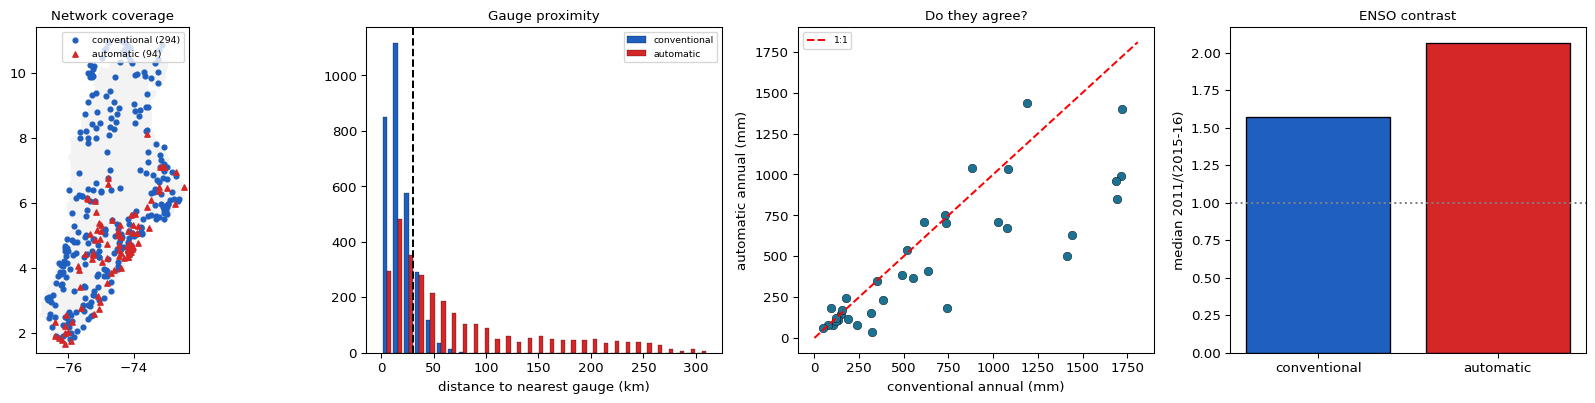

nearest-gauge distance (median km): conventional 16 | automatic 46
basin >30 km from a gauge        : conventional 17 % | automatic 63 %
co-located pairs (<12 km)        : 35   median daily r 0.32
automatic / conventional annual  : 0.81  -> automatic under-catches ~19 %
ENSO ratio: conventional 1.57x | automatic 2.06x


In [3]:
ys, xs = np.where(lab > 0)
pick = np.random.RandomState(0).choice(len(ys), 3000, replace=False)
plon = tf.c + (xs[pick]+.5)*tf.a; plat = tf.f + (ys[pick]+.5)*tf.e

def nearest(g):
    return np.min(km(plat[:, None], plon[:, None], g.lat.values[None, :], g.lon.values[None, :]), axis=1)
d_cv, d_au = nearest(cv), nearest(au)

xa, xd, cors = [], [], []
for _, a in au.iterrows():
    dist = km(a.lat, a.lon, cv.lat, cv.lon)
    j = dist.idxmin()
    if dist.loc[j] < 12:
        A = aud[aud.code == a.code]; Dd = cvd[cvd.code == cv.loc[j, 'code']]
        mm = A.merge(Dd, on='date')
        mm = mm[(mm.date.dt.year >= 2015) & (mm.date.dt.year <= 2016)]
        if len(mm) > 60:
            xa.append(mm.p_mm.sum()/2); xd.append(mm.precip_mm.sum()/2)
            cors.append(mm.p_mm.corr(mm.precip_mm))
xa, xd = np.array(xa), np.array(xd)

def enso(dd, val):
    a = dd[dd.date.dt.year == 2011].groupby('code')[val].agg(m='mean', n='size')
    b = dd[dd.date.dt.year.isin([2015, 2016])].groupby('code')[val].agg(m='mean', n='size')
    p = a.join(b, lsuffix='11', rsuffix='56', how='inner')
    return p[(p.n11 >= 150) & (p.n56 >= 300)]
pc, pa = enso(cvd, 'precip_mm'), enso(aud, 'p_mm')

fig, ax = plt.subplots(1, 4, figsize=(17.5, 4.3))
ax[0].imshow(BASIN, extent=EXT, origin='upper', cmap='Greys', vmin=0, vmax=4, alpha=.3)
ax[0].scatter(cv.lon, cv.lat, s=13, c='#1f5fbf', label=f'conventional ({cv.code.nunique()})')
ax[0].scatter(au.lon, au.lat, s=16, c='#d62728', marker='^', label=f'automatic ({au.code.nunique()})')
ax[0].legend(fontsize=7); ax[0].set_title('Network coverage', fontsize=10)
ax[1].hist([d_cv, d_au], bins=30, color=['#1f5fbf', '#d62728'],
           label=['conventional', 'automatic'], edgecolor='k', lw=.2)
ax[1].axvline(30, color='k', ls='--'); ax[1].set_xlabel('distance to nearest gauge (km)')
ax[1].legend(fontsize=7); ax[1].set_title('Gauge proximity', fontsize=10)
mx = max(xa.max(), xd.max())*1.05
ax[2].scatter(xd, xa, s=42, c='#1C7293', edgecolor='k', lw=.3)
ax[2].plot([0, mx], [0, mx], 'r--', label='1:1')
ax[2].set_xlabel('conventional annual (mm)'); ax[2].set_ylabel('automatic annual (mm)')
ax[2].legend(fontsize=7); ax[2].set_title('Do they agree?', fontsize=10)
ax[3].bar(['conventional', 'automatic'], [(pc.m11/pc.m56).median(), (pa.m11/pa.m56).median()],
          color=['#1f5fbf', '#d62728'], edgecolor='k')
ax[3].axhline(1, color='grey', ls=':'); ax[3].set_ylabel('median 2011/(2015-16)')
ax[3].set_title('ENSO contrast', fontsize=10)
plt.tight_layout(); plt.show()

print(f'nearest-gauge distance (median km): conventional {np.median(d_cv):.0f} | automatic {np.median(d_au):.0f}')
print(f'basin >30 km from a gauge        : conventional {100*(d_cv>30).mean():.0f} % | automatic {100*(d_au>30).mean():.0f} %')
print(f'co-located pairs (<12 km)        : {len(xa)}   median daily r {np.median(cors):.2f}')
print(f'automatic / conventional annual  : {np.median(xa/xd):.2f}  '
      f'-> automatic under-catches ~{100*(1-np.median(xa/xd)):.0f} %')
print(f'ENSO ratio: conventional {(pc.m11/pc.m56).median():.2f}x | automatic {(pa.m11/pa.m56).median():.2f}x')

## 3 - CHIRPS vs the repaired conventional gauges

CHIRPS v2.0, 0.05 deg daily, satellite infrared blended with gauges, now downloaded for the full
**2009-2017** window that ERA5-Land also covers. Compared nearest-pixel to every gauge.

The gauges are the reference, with one caveat stated up front: a gauge is truth *at a point*, a CHIRPS
cell is an area average over ~5 km. Some disagreement is scale mismatch, not error. What we look for is
*systematic* behaviour - volume bias, wet-day frequency, and the extreme tail.

**The day-definition test.** The conventional variable is `dia pluviometrico`: the observer reads the
gauge each morning (IDEAM convention 07:00), so a gauge "day" runs 07:00->07:00 local while CHIRPS is
built on a different clock. A storm at 22:00 lands on *different calendar days* in the two records,
which depresses daily correlation without either being wrong. Shifting CHIRPS by +/-1 day and taking
the best alignment separates a timing artefact from a genuine skill deficit.

CHIRPS years [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]  grid {'time': 3287, 'latitude': 202, 'longitude': 96}



lag  median r   bias %
 -2    0.093    -14.8   
 -1    0.304    -10.2   <- best
  0    0.160    -12.3   
  1    0.136    -13.9   
  2    0.107    -14.9   



aligned at lag -1: 275 gauges, 624,910 paired station-days
  daily r 0.30 | bias -7.6 % | RMSE 12.1 mm/day
  wet-day freq  gauge 42.7 % vs CHIRPS 42.8 % (-2.6 pts)
  P99 ratio CHIRPS/gauge 0.72   max-day ratio 0.70


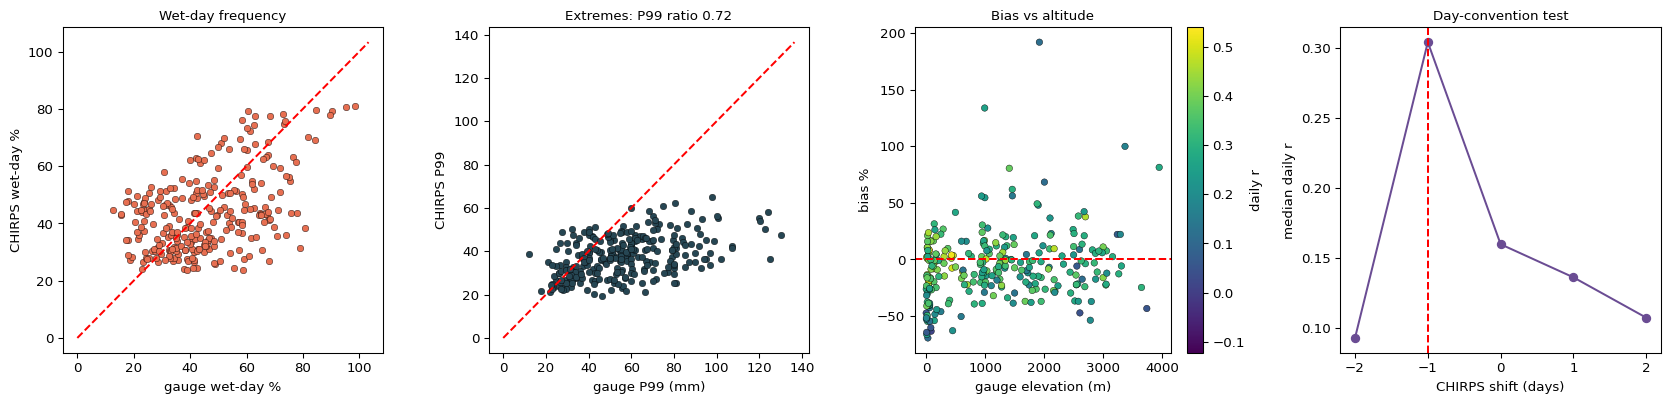

In [4]:
import xarray as xr
files = sorted(glob.glob(str(clim/'chirps_basin_*.nc')))
ch = xr.concat([xr.open_dataset(f) for f in files], dim='time').sortby('time')
pr = ch['precip'].where(ch['precip'] >= 0)
yrs = sorted({int(pathlib.Path(f).stem.split('_')[-1]) for f in files})
print(f'CHIRPS years {yrs}  grid {dict(pr.sizes)}')

sta = cv.reset_index(drop=True)
px = pr.sel(latitude=xr.DataArray(sta.lat.values, dims='st'),
            longitude=xr.DataArray(sta.lon.values, dims='st'), method='nearest').load()
chd = pd.DataFrame(px.values, index=pd.to_datetime(px.time.values), columns=sta.code.values)
gg = cvd[cvd.date.dt.year.isin(yrs)][['code', 'date', 'precip_mm']]

def pair_at(lag):
    s = chd.copy(); s.index = s.index + pd.Timedelta(days=lag)
    cl = s.stack().rename('chirps_mm').rename_axis(['date', 'code']).reset_index()
    return gg.merge(cl, on=['code', 'date'], how='inner').dropna()

lags = {}
for lag in (-2, -1, 0, 1, 2):
    p = pair_at(lag)
    r = p.groupby('code').apply(
        lambda d: d.precip_mm.corr(d.chirps_mm) if len(d) >= 300 else np.nan, include_groups=False)
    lags[lag] = (r.median(), 100*(p.chirps_mm.sum()/p.precip_mm.sum()-1))
best = max(lags, key=lambda k: lags[k][0])
print('\nlag  median r   bias %')
for k, (r, b) in lags.items():
    print(f'{k:>3}   {r:6.3f}   {b:+6.1f}   {"<- best" if k == best else ""}')

pair = pair_at(best)

def mets(d):
    tg, tc = d.precip_mm.sum(), d.chirps_mm.sum()
    return pd.Series({'n': len(d), 'r': d.precip_mm.corr(d.chirps_mm),
                      'bias_pct': 100*(tc/tg-1) if tg > 0 else np.nan,
                      'rmse': np.sqrt(((d.chirps_mm-d.precip_mm)**2).mean()),
                      'wet_g': 100*(d.precip_mm > 1).mean(), 'wet_c': 100*(d.chirps_mm > 1).mean(),
                      'p99_g': d.precip_mm.quantile(.99), 'p99_c': d.chirps_mm.quantile(.99),
                      'max_g': d.precip_mm.max(), 'max_c': d.chirps_mm.max()})
M = pair.groupby('code').apply(mets, include_groups=False)
M = M[M.n >= 300].join(sta.set_index('code')[['alt', 'zona']])
CH = {'p99': (M.p99_c/M.p99_g).median(), 'wet_d': (M.wet_c-M.wet_g).median(),
      'bias': M.bias_pct.median(), 'r': M.r.median()}

print(f'\naligned at lag {best}: {len(M)} gauges, {len(pair):,} paired station-days')
print(f'  daily r {CH["r"]:.2f} | bias {CH["bias"]:+.1f} % | RMSE {M.rmse.median():.1f} mm/day')
print(f'  wet-day freq  gauge {M.wet_g.median():.1f} % vs CHIRPS {M.wet_c.median():.1f} % '
      f'({CH["wet_d"]:+.1f} pts)')
print(f'  P99 ratio CHIRPS/gauge {CH["p99"]:.2f}   max-day ratio {(M.max_c/M.max_g).median():.2f}')

fig, ax = plt.subplots(1, 4, figsize=(17.5, 4.3))
lw_ = max(M.wet_g.max(), M.wet_c.max())*1.05
ax[0].scatter(M.wet_g, M.wet_c, s=24, c='#e76f51', edgecolor='k', lw=.3)
ax[0].plot([0, lw_], [0, lw_], 'r--'); ax[0].set_xlabel('gauge wet-day %')
ax[0].set_ylabel('CHIRPS wet-day %'); ax[0].set_title('Wet-day frequency', fontsize=10)
mx9 = max(M.p99_g.max(), M.p99_c.max())*1.05
ax[1].scatter(M.p99_g, M.p99_c, s=24, c='#264653', edgecolor='k', lw=.3)
ax[1].plot([0, mx9], [0, mx9], 'r--'); ax[1].set_xlabel('gauge P99 (mm)')
ax[1].set_ylabel('CHIRPS P99'); ax[1].set_title(f'Extremes: P99 ratio {CH["p99"]:.2f}', fontsize=10)
sc = ax[2].scatter(M.alt, M.bias_pct, s=24, c=M.r, cmap='viridis', edgecolor='k', lw=.3)
plt.colorbar(sc, ax=ax[2], label='daily r')
ax[2].axhline(0, color='r', ls='--'); ax[2].set_xlabel('gauge elevation (m)')
ax[2].set_ylabel('bias %'); ax[2].set_title('Bias vs altitude', fontsize=10)
ax[3].plot(list(lags), [v[0] for v in lags.values()], 'o-', color='#6a4c93')
ax[3].axvline(best, color='r', ls='--'); ax[3].set_xlabel('CHIRPS shift (days)')
ax[3].set_ylabel('median daily r'); ax[3].set_title('Day-convention test', fontsize=10)
plt.tight_layout(); plt.show()

## 4 - The test that changed the conclusion: how good is *our own* field?

The previous version of this notebook rejected raw CHIRPS because it damps extremes, and never asked
the same question of the gauge interpolation that would replace it. That was not a fair comparison.

Here the identical metric is applied to our own IDW field by leave-one-out: each gauge is removed, its
value predicted from the remaining gauges exactly as notebook 11 does for an ungauged minibacia, and
the predicted P99 and wet-day frequency are compared with the observed ones. This is the honest
analogue of the CHIRPS test, because most of the basin *is* ungauged.

                            P99 ratio  wet-day error (pts)  bias %  daily r
IDW gauges (leave-one-out)       0.73                18.08    1.24      0.4
CHIRPS (raw)                     0.72                -2.59   -7.61      0.3

absolute wet-day error: IDW 18.1 pts vs CHIRPS 2.6 pts


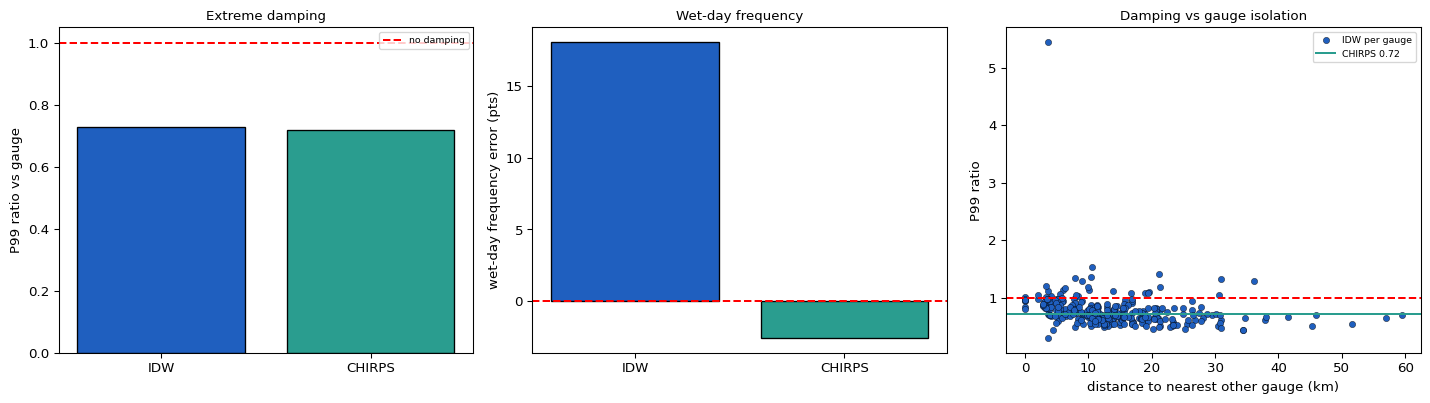

In [5]:
Wm = (cvd.pivot_table(index='date', columns='code', values='precip_mm')
          .reindex(columns=sta.code.values))
Gv = Wm.values.astype('float32'); obs = ~np.isnan(Gv); Gf = np.where(obs, Gv, 0).astype('float32')
Dg = km(sta.lat.values[:, None], sta.lon.values[:, None],
        sta.lat.values[None, :], sta.lon.values[None, :])
np.fill_diagonal(Dg, np.inf)
gn = np.argsort(Dg, axis=1)[:, :6]; gdk = np.take_along_axis(Dg, gn, 1)
gW = (1./np.maximum(gdk, 1.)**2).astype('float32')
pred = np.full(Gv.shape, np.nan, dtype='float32')
for j in range(len(sta)):
    num = (Gf[:, gn[j]]*gW[j]).sum(1); den = (obs[:, gn[j]]*gW[j]).sum(1)
    with np.errstate(invalid='ignore', divide='ignore'):
        pred[:, j] = np.where(den > 0, num/den, np.nan)
okm = obs & ~np.isnan(pred)

rows = []
for j in range(len(sta)):
    m = okm[:, j]
    if m.sum() < 300:
        continue
    o, p = Gv[m, j], pred[m, j]
    q = np.quantile(o, .99)
    rows.append({'r': float(np.corrcoef(o, p)[0, 1]),
                 'bias_pct': 100*(p.sum()/o.sum()-1) if o.sum() > 0 else np.nan,
                 'p99_ratio': np.quantile(p, .99)/q if q > 0 else np.nan,
                 'wet_g': 100*(o > 1).mean(), 'wet_p': 100*(p > 1).mean(),
                 'd_km': float(gdk[j, 0])})
L = pd.DataFrame(rows)
IDW = {'p99': L.p99_ratio.median(), 'wet_d': (L.wet_p-L.wet_g).median(),
       'bias': L.bias_pct.median(), 'r': L.r.median()}

cmp_ = pd.DataFrame({'IDW gauges (leave-one-out)': IDW, 'CHIRPS (raw)': CH}).T
cmp_.columns = ['P99 ratio', 'wet-day error (pts)', 'bias %', 'daily r']
print(cmp_.round(2).to_string())
print(f'\nabsolute wet-day error: IDW {abs(IDW["wet_d"]):.1f} pts vs CHIRPS {abs(CH["wet_d"]):.1f} pts')

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
lbl = ['IDW', 'CHIRPS']
ax[0].bar(lbl, [IDW['p99'], CH['p99']], color=['#1f5fbf', '#2a9d8f'], edgecolor='k')
ax[0].axhline(1, color='r', ls='--', label='no damping')
ax[0].set_ylabel('P99 ratio vs gauge'); ax[0].legend(fontsize=7)
ax[0].set_title('Extreme damping', fontsize=10)
ax[1].bar(lbl, [IDW['wet_d'], CH['wet_d']], color=['#1f5fbf', '#2a9d8f'], edgecolor='k')
ax[1].axhline(0, color='r', ls='--'); ax[1].set_ylabel('wet-day frequency error (pts)')
ax[1].set_title('Wet-day frequency', fontsize=10)
ax[2].scatter(L.d_km, L.p99_ratio, s=22, c='#1f5fbf', edgecolor='k', lw=.3, label='IDW per gauge')
ax[2].axhline(CH['p99'], color='#2a9d8f', label=f'CHIRPS {CH["p99"]:.2f}')
ax[2].axhline(1, color='r', ls='--')
ax[2].set_xlabel('distance to nearest other gauge (km)'); ax[2].set_ylabel('P99 ratio')
ax[2].legend(fontsize=7); ax[2].set_title('Damping vs gauge isolation', fontsize=10)
plt.tight_layout(); plt.show()

## 5 - Verdict

### Preprocessing (section 1)

55 of 294 stations were zero-suppressed and are now repaired. This had to be fixed first: it inflated
some annual totals to 9,000-12,000 mm/yr and produced a wet bias centred on those stations in the
interpolated field. Any conclusion drawn before the repair - including the earlier version of this
notebook - rested on corrupted input.

### Which gauge network (section 2): **conventional**

The automatic network under-catches substantially, sits far sparser, and carries no IDEAM approval
flag. Its one real advantage, sub-hourly resolution, is discarded at the first step of a daily model.

The under-catch matters more than the sparsity. A biased input does not merely add noise: calibration
would compensate by mis-tuning the soil parameters, producing the right discharge from the wrong
physics - and MGB-SED then inherits that error twice, once through the corrupted parameters and again
through under-stated rainfall driving MUSLE.

### Gauges or CHIRPS (sections 3-4): **neither alone**

The earlier verdict said raw CHIRPS must be rejected because it damps extremes. Section 4 shows our
own gauge interpolation damps them by an **essentially identical** amount. Extreme damping is therefore
not a discriminator - it is a property of representing point rainfall as an areal field, which both
methods must do. Part of it is even physically correct: MGB needs *areal* rainfall, and a true areal
average genuinely has more wet days and lower peaks than a point gauge. What we cannot do is separate
correct areal smoothing from excessive interpolation smoothing.

What actually distinguishes them:

| | Gauges (repaired) | CHIRPS |
|---|---|---|
| Nature | measurement at 294 points | estimate everywhere |
| Ungauged 17 % of basin | extrapolated | covered |
| Extreme damping | present | present, same magnitude |
| Wet-day frequency | inflated by interpolation | closer to gauge truth |
| ENSO contrast | reference | reproduced |

The split is not accuracy versus inaccuracy but **accuracy without coverage** versus **coverage
without accuracy**. MGB demands a value for every minibacia every day; the science demands those values
be defensible. Neither source satisfies both alone.

### Decision

**Gauges set the values; CHIRPS sets the spatial pattern between them.** Quantile-map CHIRPS onto the
repaired gauge network - stratified by elevation band and hydrographic zone, because the bias is
structured rather than uniform - then merge conditionally so gauges dominate where they exist and the
corrected field carries the ungauged headwaters. ERA5-Land supplies only the energy variables for
Penman-Monteith PET; its own precipitation is not used.

Quantile mapping rather than simple scaling, for a reason that is now measured: a single multiplicative
factor fixing the volume bias would leave the extreme tail and the wet-day frequency uncorrected, and
those are the two properties that drive MUSLE erosion.

### Stated limitations

1. **The ungauged headwaters stay uncertain under any method.** A data-availability limit of this
   basin, not a modelling choice - it belongs in the uncertainty discussion rather than hidden.
2. **The day-convention offset is real** (section 3) and must be resolved before calibrating against
   hydrographs, or the routing and recession parameters will absorb a timing error and appear well
   calibrated for the wrong reason.
3. **Gauge density is not constant in time** (~183 stations/day in 2011 vs ~153 in 2015-16), so the
   ENSO ratio should be recomputed on a fixed station set before it is quoted in the report.
4. **The 5-20 % dry-fraction band was left untouched.** 65 stations sit between clearly healthy and
   clearly suppressed; the 0.15 threshold is conservative and their sensitivity is untested.